## **1ª Análise Exploratória**: Análise Inicial e Limpeza do Dataset ##

[Link do Dataset no Kaggle](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)

In [51]:
import pandas as pd
import ast
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('archive/movies_metadata.csv')
pd.set_option('display.max_columns', 100)

Análise Exploratória do Dataset

In [52]:
# Vamos começar conhecendo melhor as features (variáveis independentes) que possuímos
df.head(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45463 non-null  bool   
 1   belongs_to_collection  4491 non-null   object 
 2   budget                 45463 non-null  int64  
 3   genres                 45463 non-null  object 
 4   homepage               7779 non-null   object 
 5   id                     45463 non-null  int64  
 6   imdb_id                45446 non-null  object 
 7   original_language      45452 non-null  object 
 8   original_title         45463 non-null  object 
 9   overview               44509 non-null  object 
 10  popularity             45463 non-null  float64
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [53]:
df.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92


Antes de qualquer coisa, vamos conferir se não há duplicatas com base na coluna id

In [54]:
# Filtrando apenas as linhas onde o ID se repete
duplicados = df[df.duplicated(subset=['id'], keep=False)]

print(len(duplicados))
# Ordenando para ver os pares lado a lado
duplicados.sort_values(by='id').head(5)

59


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
5865,False,NaN,30000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam...",NaN,4912,tt0270288,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",11.331072,/o3Im9nPLAgtlw1j2LtpMebAotSe.jpg,"[{'name': 'Miramax Films', 'id': 14}, {'name':...","[{'iso_3166_1': 'US', 'name': 'United States o...",2002-12-30,33013805,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Some things are better left top secret.,Confessions of a Dangerous Mind,False,6.6,281
33824,False,NaN,30000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam...",NaN,4912,tt0270288,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",7.645827,/o3Im9nPLAgtlw1j2LtpMebAotSe.jpg,"[{'name': 'Miramax Films', 'id': 14}, {'name':...","[{'iso_3166_1': 'US', 'name': 'United States o...",2002-12-30,33013805,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Some things are better left top secret.,Confessions of a Dangerous Mind,False,6.6,281
9165,False,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",NaN,5511,tt0062229,fr,Le Samouraï,Hitman Jef Costello is a perfectionist who alw...,9.091288,/cvNW8IXigbaMNo4gKEIps0NGnhA.jpg,"[{'name': 'Fida cinematografica', 'id': 73}, {...","[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...",1967-10-25,39481,105.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,There is no solitude greater than that of the ...,Le Samouraï,False,7.9,187
7345,False,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",NaN,5511,tt0062229,fr,Le Samouraï,Hitman Jef Costello is a perfectionist who alw...,9.091288,/cvNW8IXigbaMNo4gKEIps0NGnhA.jpg,"[{'name': 'Fida cinematografica', 'id': 73}, {...","[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...",1967-10-25,39481,105.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,There is no solitude greater than that of the ...,Le Samouraï,False,7.9,187
44818,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,6.480376,/5ILjS6XB5deiHop8SXPsYxXWVPE.jpg,"[{'name': 'TV Tokyo', 'id': 3034}, {'name': '4...","[{'iso_3166_1': 'JP', 'name': 'Japan'}]",2000-07-08,68411275,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,144


In [55]:
# Remove as duplicatas mantendo apenas a primeira ocorrência
df = df.drop_duplicates(subset=['id'], keep='first')

# Verificando se agora os valores batem
print(f"Novo total de linhas: {len(df)}")
print(f"Total de IDs únicos: {df['id'].nunique()}")

Novo total de linhas: 45433
Total de IDs únicos: 45433


Agora, vamos eliminar algumas variáveis que não serão aplicadas ao modelo. As selecionadas foram as seguintes:

- homepage: Página de publicidade do filme
- poster_path: ID do banner do filme (Localizável em: image.tmdb.org/t/p/w185/ID)
- status: Se já foi lançado ou não (Como o Dataset é de 2017, todos os filmes já devem ter sido lançados)
- video: 
- production_companies: A produtora do filme é irrelevante
- tagline: Slogan

In [56]:
df.drop(['homepage', 'poster_path', 'status', 'video', 'production_companies', 'tagline'], axis=1, inplace= True)

In [57]:
df.head(3)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Grumpier Old Men,6.5,92


Como podemos observar, as variáveis a seguir foram categorizadas como object, quando na realidade deveriam ser numéricas ou booleanos
- adult: Booleano (False/True)
- budget: Numérico (Dinheiro)
- release_date: Numérico (Data de Lançamento)
- popularity: Numérico (Visualizações)

In [58]:
# Conferindo se há valores além de "True" e "False" na coluna
df['adult'].unique()

array([False,  True])

In [59]:
# Substituindo as strings "True" e "False" pelos valores booleanos
df['adult'] = df['adult'] == 'True'

In [60]:
# Analisando quais são os caracteres presentes dentro da coluna budget.
df['budget'].astype(str).apply(list).explode().unique()

# Como podemos observar no Output, a coluna contém somente numerais e nenhum ponto (.), o que indica que todos os valores são números inteiros
# Isso significa que podemos seguir com a conversão para integer diretamente
df['budget'] = df['budget'].astype('Int64')

In [61]:
df['release_date'] = pd.to_datetime(df['release_date'])

In [62]:
df.head(2)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45433 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45433 non-null  bool          
 1   belongs_to_collection  4488 non-null   object        
 2   budget                 45433 non-null  Int64         
 3   genres                 45433 non-null  object        
 4   id                     45433 non-null  int64         
 5   imdb_id                45416 non-null  object        
 6   original_language      45422 non-null  object        
 7   original_title         45433 non-null  object        
 8   overview               44479 non-null  object        
 9   popularity             45433 non-null  float64       
 10  production_countries   45433 non-null  object        
 11  release_date           45349 non-null  datetime64[ns]
 12  revenue                45433 non-null  int64         
 13  runtim

In [64]:
# Para facilitar a visualização da tipagem dos dados, vamos reorganizar a tabela
nova_ordem_colunas = [
    # Booleana
    'adult',

    # Numéricas (Inteiros)
    'id', 'budget', 'revenue', 'vote_count',

    # Numéricas (Decimais / Floats)
    'popularity', 'runtime', 'vote_average',

    # Data
    'release_date',

    # Texto / Objeto (Descritivas)
    'title', 'original_title', 'overview',

    # Texto / Objeto (Listas/Metadados)
    'genres', 'belongs_to_collection', 'production_countries', 'spoken_languages',

    # Texto / Objeto (IDs/Código)
    'imdb_id', 'original_language'
]

df = df[nova_ordem_colunas]
df.head(5)

,adult,id,budget,revenue,vote_count,popularity,runtime,vote_average,release_date,title,original_title,overview,genres,belongs_to_collection,production_countries,spoken_languages,imdb_id,original_language
0,False,862,30000000,373554033,5415,21.946943,81.0,7.7,1995-10-30,Toy Story,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","{'id': 10194, 'name': 'Toy Story Collection', ...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114709,en
1,False,8844,65000000,262797249,2413,17.015539,104.0,6.9,1995-12-15,Jumanji,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",tt0113497,en
2,False,15602,0,0,92,11.712900,101.0,6.5,1995-12-22,Grumpier Old Men,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","{'id': 119050, 'name': 'Grumpy Old Men Collect...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113228,en
3,False,31357,16000000,81452156,34,3.859495,127.0,6.1,1995-12-22,Waiting to Exhale,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114885,en
4,False,11862,0,76578911,173,8.387519,106.0,5.7,1995-02-10,Father of the Bride Part II,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]","{'id': 96871, 'name': 'Father of the Bride Col...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113041,en


In [65]:
# Por último, a coluna belongs_to_collection possui 90% dos seus valores como NaN. Isso será um problema no treinamento do modelo.
# Para reverter isso, vamos desserializar os dados, convertendo todos para dicionários, incluindo os valores nulos
df['belongs_to_collection'] = df['belongs_to_collection'].apply(
    lambda x: x if pd.notna(x) else {} # Os valores NaN serão convertidos em dicionários vazios {}
)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45433 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45433 non-null  bool          
 1   id                     45433 non-null  int64         
 2   budget                 45433 non-null  Int64         
 3   revenue                45433 non-null  int64         
 4   vote_count             45433 non-null  int64         
 5   popularity             45433 non-null  float64       
 6   runtime                45176 non-null  float64       
 7   vote_average           45433 non-null  float64       
 8   release_date           45349 non-null  datetime64[ns]
 9   title                  45433 non-null  object        
 10  original_title         45433 non-null  object        
 11  overview               44479 non-null  object        
 12  genres                 45433 non-null  object        
 13  belong

## **2ª Análise Exploratória**: Duração do Filme ##

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # O Seaborn facilita a criação de gráficos estatísticos e usa o Matplotlib por baixo dos panos

# Configuração básica para visualização (opcional)
sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = (10, 6) # Define um tamanho padrão para os gráficos

Vamos usar um histograma para visualizar qual a duração mais comuns dos filmes presentes no Dataset

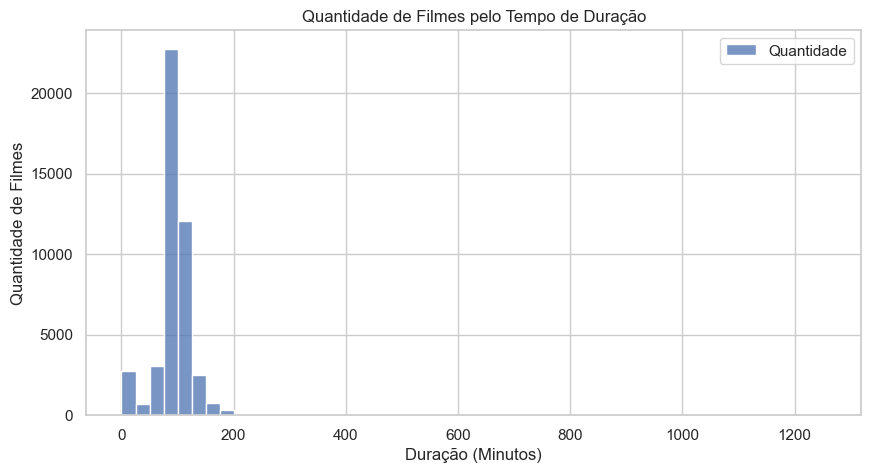

In [68]:
# Histograma: Mostra a distribuição de uma única variável
plt.figure(figsize=(10, 5))
sns.histplot(df['runtime'].dropna(), kde=False, bins=50) 
# Usamos dropna() para ignorar os NaNs
# kde=True adiciona uma estimativa da densidade (suaviza a curva)
plt.title('Quantidade de Filmes pelo Tempo de Duração')
plt.xlabel('Duração (Minutos)')
plt.ylabel('Quantidade de Filmes')
plt.legend(['Quantidade', 'Tempo'])
plt.show()

In [69]:
# Aqui, como temos poucas linhas NaN (cerca de 200), vamos removê-las do Dataset
df = df.dropna(subset=['runtime'])

# Vamos definir uma função que atribua uma categoria de acordo com a duração do filme
def categorizar_duracao(runtime):
    if runtime < 15:
        return "Very Short"
    
    elif 15 <= runtime < 60: # < 1hr
        return "Short"
    
    elif 60 <= runtime < 90: # De 1 a 1,5
        return "Short-Medium"
    
    elif 90 <= runtime < 120: # De 1,5 a 2
        return "Medium-Long"
    
    elif 120 <= runtime < 180: # De 2 a 3
        return "Long"
    
    elif 180 <= runtime: # > 3
        return "Very Long"
    
# Aqui aplicamos a função sobre a coluna runtime, criando a nova coluna Categoria de Duração
df['runtime_category'] = df['runtime'].apply(categorizar_duracao)

runtime_category
Medium-Long     24142
Short-Medium    11509
Long             4998
Very Short       2392
Short            1539
Very Long         596
Name: count, dtype: int64


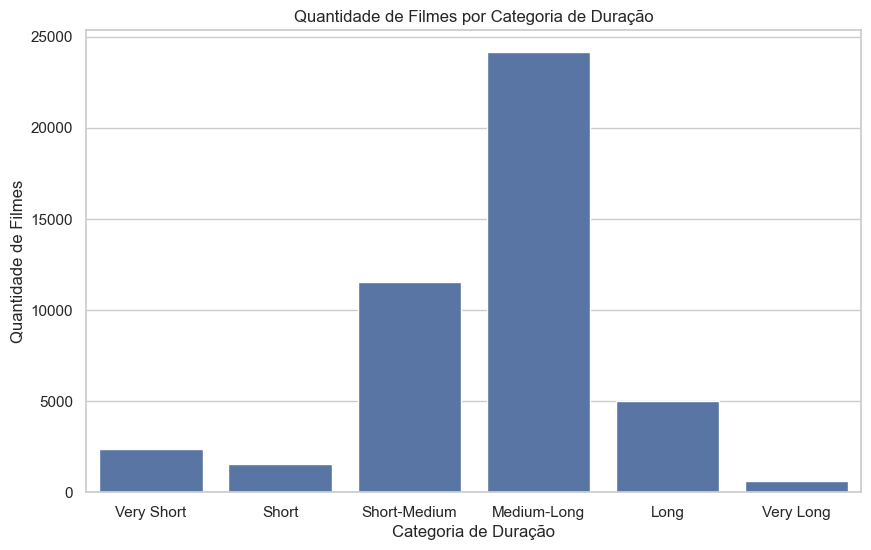

In [70]:
# Imprimir uma tabelinha com as contagens de cada categoria
print(df['runtime_category'].value_counts())

# Como estamos trabalhando com variáveis categóricas agora, vamos usar uma countplot
sns.countplot(data=df, x='runtime_category', order=['Very Short', 'Short', 'Short-Medium', 'Medium-Long', 'Long', 'Very Long' ])
plt.title('Quantidade de Filmes por Categoria de Duração')
plt.xlabel('Categoria de Duração')
plt.ylabel('Quantidade de Filmes')

plt.show()

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45176 entries, 0 to 45462
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45176 non-null  bool          
 1   id                     45176 non-null  int64         
 2   budget                 45176 non-null  Int64         
 3   revenue                45176 non-null  int64         
 4   vote_count             45176 non-null  int64         
 5   popularity             45176 non-null  float64       
 6   runtime                45176 non-null  float64       
 7   vote_average           45176 non-null  float64       
 8   release_date           45103 non-null  datetime64[ns]
 9   title                  45176 non-null  object        
 10  original_title         45176 non-null  object        
 11  overview               44479 non-null  object        
 12  genres                 45176 non-null  object        
 13  belong

## **3ª Análise Exploratória**: Popularidade do Filme vs. Nota Média ##


Conforme é explicado no próprio [site](https://developer.themoviedb.org/docs/popularity-and-trending) da The Movie Database, a métrica de popularidade é um indicador dinâmico que reflete: quantidade de votos; quantas vezes o filme foi favoritado; quantas vezes foi adicionado à "Watchlist"

In [72]:
df[['original_title','popularity','vote_average']].sort_values('popularity', ascending=False)

,original_title,popularity,vote_average
30698,Minions,547.488298,6.4
33354,Wonder Woman,294.337037,7.2
42219,Beauty and the Beast,287.253654,6.8
43641,Baby Driver,228.032744,7.2
24454,Big Hero 6,213.849907,7.8
...,...,...,...
36190,Veljet,0.000000,0.0
20269,Preston Sturges: The Rise and Fall of an Ameri...,0.000000,0.0
40737,El pejesapo,0.000000,0.0
43766,The Challenge... A Tribute to Modern Art,0.000000,0.0


Por outro lado, a variável vote_average, que representa a nota média que o filme recebeu, também é um indicador interessante para avaliar o engajamento do telespectador.
Vamos tentar observar uma correlação entre essas duas variáveis a seguir.

In [73]:
df[['original_title','vote_average','popularity']].sort_values('vote_average', ascending=False)

,original_title,vote_average,popularity
13447,Hell to Eternity,10.0,0.157003
45359,The Many Faces of Christopher Lee,10.0,0.051939
14536,Dinosaurs! A Fun-Filled Trip Back In Time,10.0,0.004948
45195,First Round Down,10.0,0.422836
39757,Sunnyside Up,10.0,0.401213
...,...,...,...
38184,The Cockroach That Ate Cincinnati,0.0,0.001177
83,Last Summer in the Hamptons,0.0,0.531159
38111,Come Down Molly,0.0,0.333745
38112,Dial H-I-S-T-O-R-Y,0.0,0.001192


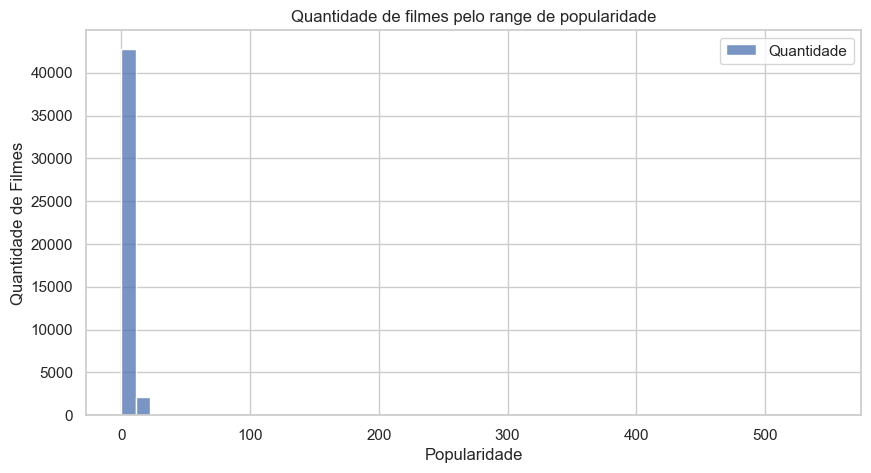

In [74]:
# Histograma: Mostra a distribuição de uma única variável
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], kde=False, bins=50) 
# kde=True adiciona uma estimativa da densidade (suaviza a curva)
plt.title('Quantidade de filmes pelo range de popularidade')
plt.xlabel('Popularidade')
plt.ylabel('Quantidade de Filmes')
plt.legend(['Quantidade'])
plt.show()

O gráfico acima demonstra que existe uma amplitude muita alta na variável *popularity*, que varia entre 0 e 500. Para contornar isso, vamos seguir com uma **Normalização Logarítmica**, reescalonando essa feature para o intervalo de 0 a 10, sendo 10 a maior nota presente no Dataset.

In [75]:
import numpy as np

# 1. Aplicamos o log1p
log_pop = np.log1p(df['popularity'])

# 2. Reescalonamos para que o máximo seja 10
# Dividimos pelo valor máximo do log para ficar entre 0 e 1, depois multiplicamos por 10
df['popularity_norm'] = (log_pop / log_pop.max()) * 10

# Vamos ver como ficaram os valores agora:
display(df[['original_title','popularity', 'popularity_norm']].sort_values('popularity', ascending=False).head(10))

,original_title,popularity,popularity_norm
30698,Minions,547.488298,10.000000
33354,Wonder Woman,294.337037,9.018499
42219,Beauty and the Beast,287.253654,8.980009
43641,Baby Driver,228.032744,8.615383
24454,Big Hero 6,213.849907,8.514029
26563,Deadpool,187.860492,8.309609
26565,Guardians of the Galaxy Vol. 2,185.330992,8.288231
14551,Avatar,185.070892,8.286016
24350,John Wick,183.870374,8.275753
23674,Gone Girl,154.801009,8.004514


Agora sim, vamos analisar novamente o gráfico com os valores normalizados

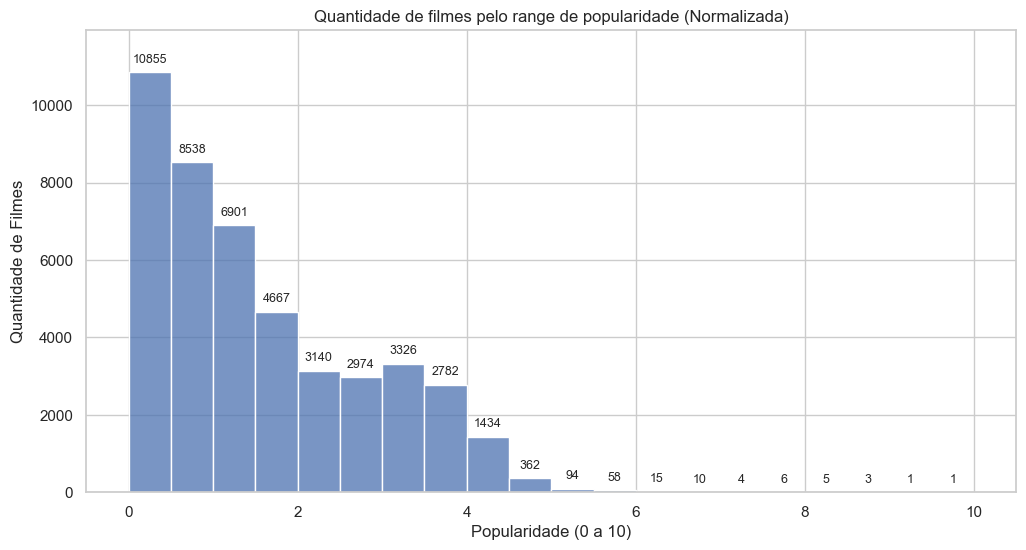

In [76]:
# Histograma: Mostra a distribuição da popularidade normalizada
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['popularity_norm'], kde=False, bins=20)

# Adicionando rótulos de dados em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.title('Quantidade de filmes pelo range de popularidade (Normalizada)')
plt.xlabel('Popularidade (0 a 10)')
plt.ylabel('Quantidade de Filmes')

# Melhorando o limite do eixo Y para o texto não cortar no topo
plt.ylim(0, df['popularity_norm'].value_counts(bins=20).max() * 1.1)

plt.show()

Claramente existe uma enorme concentração de filmes com baixíssima popularidade, mas isso está relacionado à sua nota média? <br>

Text(0, 0.5, 'Nota Média (0 a 10)')

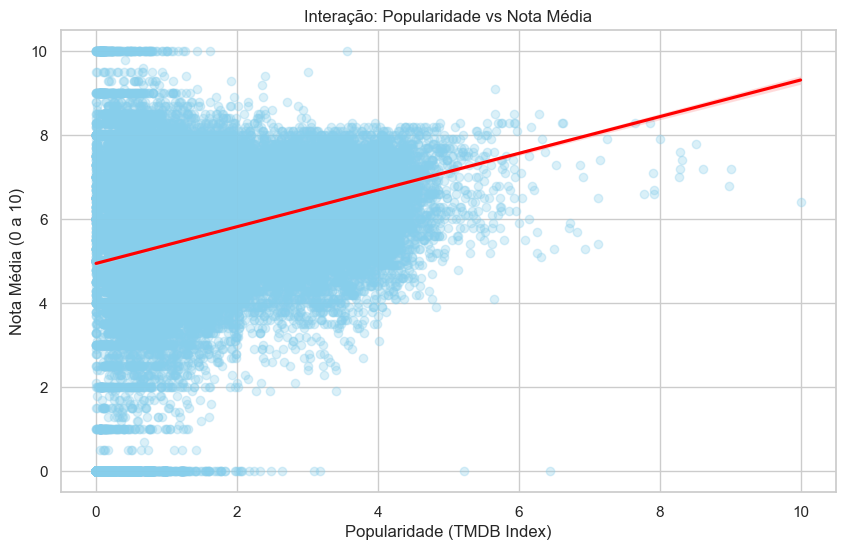

In [77]:
sns.regplot(data=df, x='popularity_norm', y='vote_average',

            scatter_kws={'alpha':0.3, 'color':'skyblue'},

            line_kws={'color':'red'})

plt.title('Interação: Popularidade vs Nota Média')

plt.xlabel('Popularidade (TMDB Index)')

plt.ylabel('Nota Média (0 a 10)')

Conforme imaginamos, o gráfico apresentado acima demonstra que existe uma linearidade considerável entre as *features popularity* e *note_average*.<br>
No entanto, devido ao gráfico ser todo da mesma cor, ainda não foi possível ver onde há maior concentração de filmes. Vamos analisar no gráfico a seguir.

Porcentagem do Dataset Analisado: 1.0
Filmes incluidos no filtro: 45176/45176


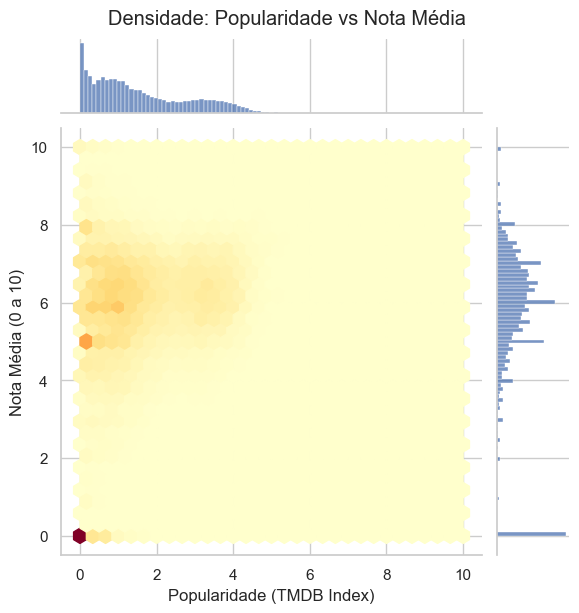

In [78]:
# Filtro simples
# df_analise = df.loc[df['popularity_norm'] > 0.5]
df_analise = df

pct_dataset_analisado = round(len(df_analise)/len(df),5)
print('Porcentagem do Dataset Analisado:',pct_dataset_analisado)
print('Filmes incluidos no filtro:', f"{len(df_analise)}"+f"/{len(df)}")

# O jointplot cria o gráfico de dispersão com "hexágonos" de calor
# e ainda adiciona histogramas nas bordas para ver o acúmulo nos eixos
g = sns.jointplot(data=df_analise, x='popularity_norm', y='vote_average',
                  kind='hex', cmap='YlOrRd', gridsize=30)

# Ajustando títulos e nomes de eixos
g.fig.suptitle('Densidade: Popularidade vs Nota Média', y=1.02)
g.set_axis_labels('Popularidade (TMDB Index)', 'Nota Média (0 a 10)')

plt.show()

O nosso algoritmo não tem como objetivo discriminar filmes pouco conhecidos, mas sim mitigar o risco de indicar um filme mal-avaliado.<br>Vamos então analisar os impactos de remover este acúmulo de filmes encontrado próximo a 0 de popularidade e 0 de nota média.

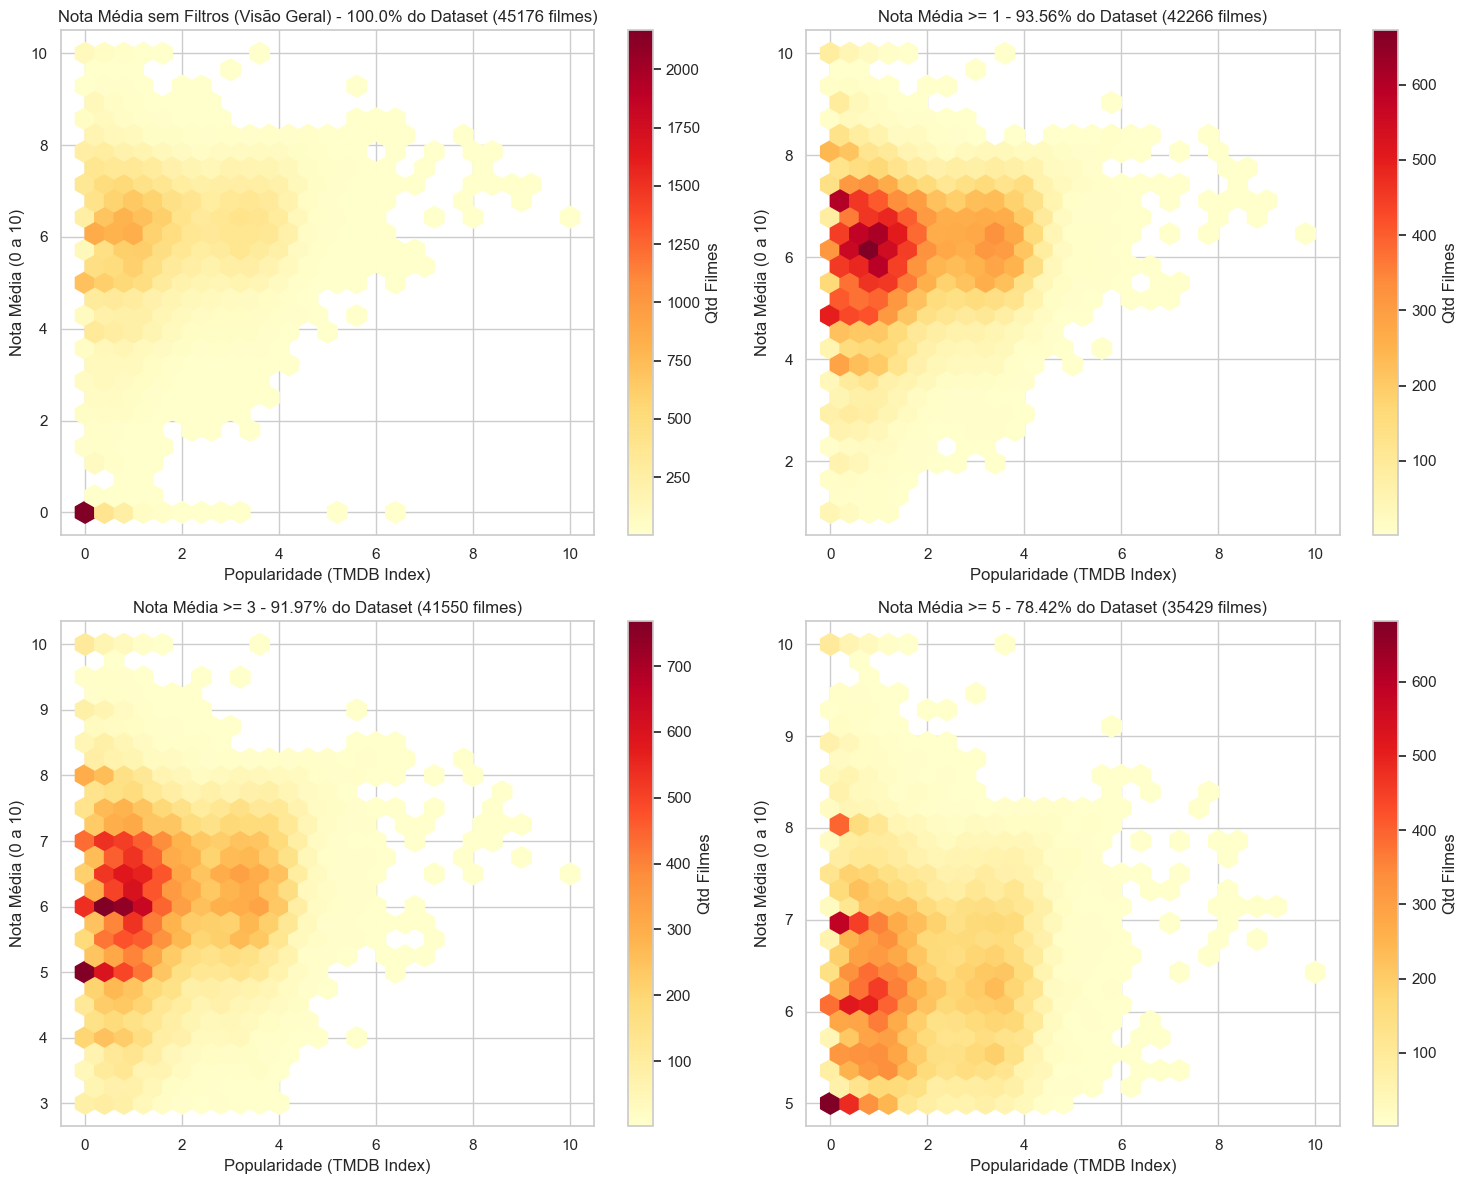

In [82]:
# Configuração da figura (2x2)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# --- 1. Sem filtros
df_1 = df
hb1 = axs[0, 0].hexbin(df_1['popularity_norm'], df_1['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[0, 0].set_title(f"Nota Média sem Filtros (Visão Geral) - {round(len(df_1)/len(df)*100, 2)}% do Dataset ({len(df_1)} filmes)")
plt.colorbar(hb1, ax=axs[0, 0], label='Qtd Filmes')

# --- 4. Filtro: Nota Média > 1 ---
df_2 = df.loc[df['vote_average'] >= 1]
hb3 = axs[0, 1].hexbin(df_2['popularity_norm'], df_2['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[0, 1].set_title(f"Nota Média >= 1 - {round(len(df_2)/len(df)*100, 2)}% do Dataset ({len(df_2)} filmes)")
plt.colorbar(hb3, ax=axs[1, 0], label='Qtd Filmes')

# --- 3. Filtro: Nota Média > 3 ---
df_3 = df.loc[df['vote_average'] >= 3]
hb4 = axs[1, 0].hexbin(df_3['popularity_norm'], df_3['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[1, 0].set_title(f"Nota Média >= 3 - {round(len(df_3)/len(df)*100, 2)}% do Dataset ({len(df_3)} filmes)")
plt.colorbar(hb4, ax=axs[1, 1], label='Qtd Filmes')

# --- 2. Filtro: Nota Média > 5 ---
df_4 = df.loc[df['vote_average'] >= 5]
hb2 = axs[1, 1].hexbin(df_4['popularity_norm'], df_4['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[1, 1].set_title(f"Nota Média >= 5 - {round(len(df_4)/len(df)*100, 2)}% do Dataset ({len(df_4)} filmes)")
plt.colorbar(hb2, ax=axs[0, 1], label='Qtd Filmes')

# Padronização de nomes de eixos usando o flat
for ax in axs.flat:
    if ax.axison:
        ax.set_xlabel('Popularidade (TMDB Index)')
        ax.set_ylabel('Nota Média (0 a 10)')

plt.tight_layout()
plt.show()

Aqui nos deparamos com o seguinte Trade-Off:<br>
Evidentemente quanto maior a nota de corte, menos filmes teremos disponíveis para a recomendação.<br>
A relação é a seguinte:<br>
- Nota de corte = 1 : 93,5% do dataset original : 42.266 filmes<br>
- Nota de corte = 3 : 91,9% do dataset original : 41.550 filmes<br>
- Nota de corte = 5 : 78,4% do dataset original : 35.429 filmes<br><br>
Vamos seguir com a nota de corte em 3, preservando uma biblioteca de mais de 40 mil filmes

In [83]:
# Filtrando o dataframe original para manter apenas filmes com nota média maior que 3
df = df.loc[df['vote_average'] >= 3].reset_index(drop=True)

Claramente existe uma enorme concentração de filmes com baixíssima popularidade, mas isso está relacionado à sua nota média? <br>
Para essa nova análise, vamos utilizar a **Regressão Linear** para observar essa tendência abaixo

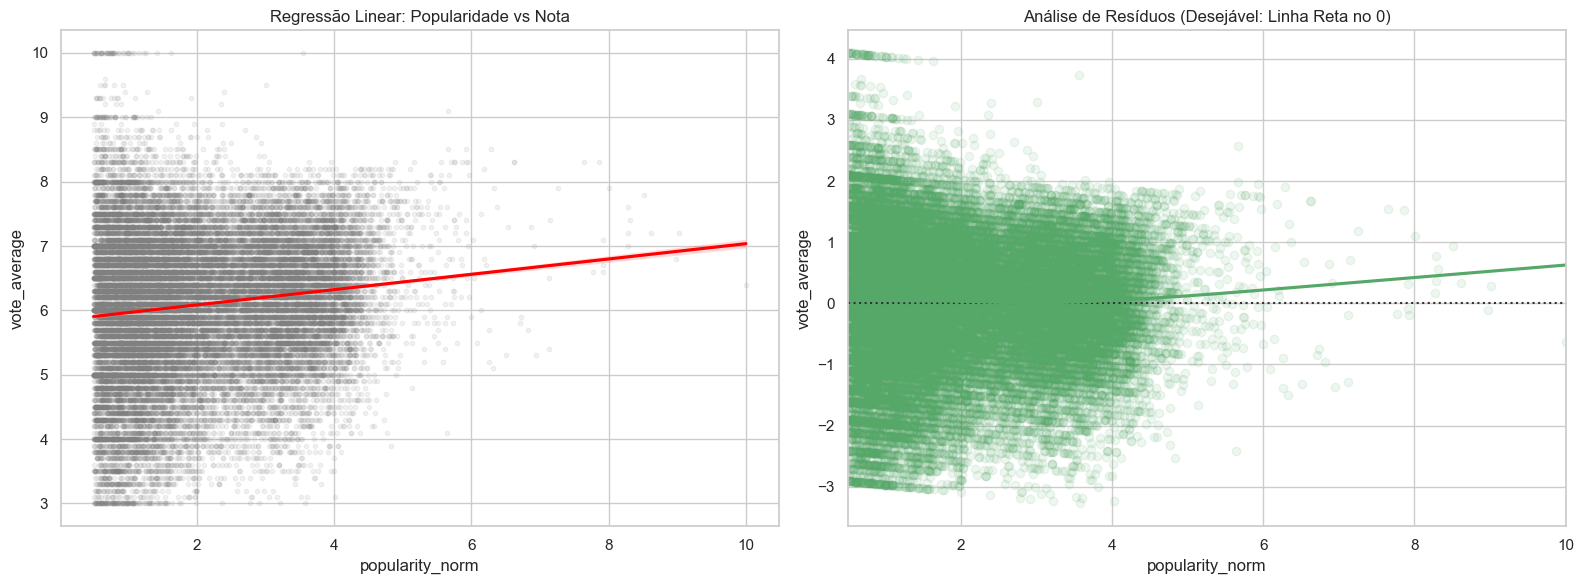

In [84]:
# Filtro para garantir dados com engajamento mínimo
df_analise = df.loc[df['popularity_norm'] > 0.5].dropna(subset=['popularity_norm', 'vote_average'])

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Regressão Linear
sns.regplot(data=df_analise, x='popularity_norm', y='vote_average', 
            scatter_kws={'alpha':0.1, 's':10, 'color':'gray'}, 
            line_kws={'color':'red'}, ax=axs[0])
axs[0].set_title('Regressão Linear: Popularidade vs Nota')

# Subplot 2: Gráfico de Resíduos (Checa se a linearidade é válida)
sns.residplot(data=df_analise, x='popularity_norm', y='vote_average', 
              lowess=True, color="g", scatter_kws={'alpha':0.1}, ax=axs[1])
axs[1].set_title('Análise de Resíduos (Desejável: Linha Reta no 0)')

plt.tight_layout()
plt.show()

O gráfico apresenta, a princípio, uma certa linearidade entre as variáveis. <br>
Porém novamente, como existe grande dispersão das notas médias apresentadas, precisamos identificar qual a confiabilidade entre a variável independente (popularidade) e variável dependente (nota média).<br>
Para isso, vamos calcular o coeficiente de Pearson (métrica estatística usada para calcular a dispersão dos pontos em torno do eixo de regressão)

In [85]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_analise['popularity_norm'], df_analise['vote_average'])
print(f"Coeficiente de Correlação de Pearson: {corr:.4f}")
print(f"P-valor: {p_value:.4e}")

Coeficiente de Correlação de Pearson: 0.1293
P-valor: 1.1792e-124


O coeficiente de Pearson varia entre -1 e +1.<br>
Como o resultado do teste (0.12) se aproxima muito de 0, isso indica que a linearidade observada nos gráficos carrega também um erro de previsão muito alto.<br><br>
A métrica p-valor calcula o quanto podemos confiar no próprio coeficiente de Pearson de acordo com o tamanho da amostra analisada, que no caso do nosso dataset, é bem grande, com 41.577 linhas.<br>
O nosso p-valor deu 9.98 e-125. Isso equivale a 0, 125 zeros seguido de 998.<br>
Ou seja, podemos ter uma confiança bem alta de que **é muito baixa** a linearidade entre as variáveis popularity e vote_average

## **4ª Análise Exploratória**: Relação entre ROI (revenue/budget) com popularidade, nota média e quantidade de votos ##

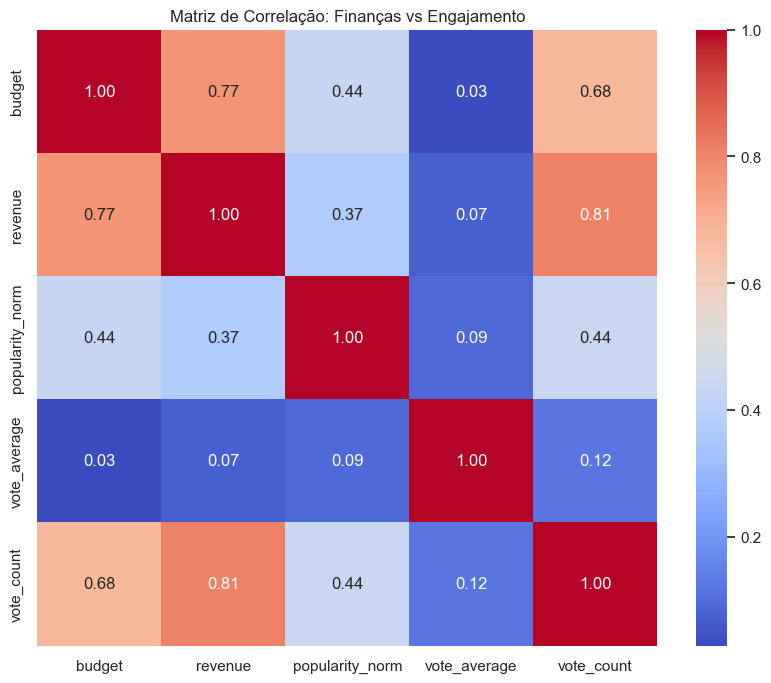

In [86]:
# Selecionando as colunas de interesse
colunas_financeiras = ['budget', 'revenue', 'popularity_norm', 'vote_average', 'vote_count']

# Calculando a correlação de Pearson para todas
matrix = df[colunas_financeiras].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação: Finanças vs Engajamento')
plt.show()

A partir do gráfico acima, podemos tirar alguns insights valiosos:
- Como já era esperado, um orçamento (budget) maior tende a alavancar a receita (revenue) do filme. Correlação de 77%.

- A quantidade de votos também tende a aumentar conforme o budget e a receita, muito provavelmente pelo montante investido com sucesso em Marketing. Correlação de 81%.

- Surpreendentemente, a correlação entre a Nota Média (vote_average) e as variáveis do ROI (orçamento e receita) é baixíssima. Isso demonstra que, na grande maioria das vezes, a avaliação positiva do público não depende de um alto investimento

A seguir, vamos analisar quais foram os 5 filmes com o maior ROI do Dataset:

In [87]:
# Calculo do ROI
df['roi'] = (df['revenue'] - df['budget']) / (df['budget'])

# Filtrando casos irreais (divisão por zero ou orçamentos simbólicos)
df_roi = df.loc[(df['budget'] > 1000) & (df['revenue'] > 0)]

print(f"Linhas remanescentes após filtro de ROI: {len(df_roi)}, {round(len(df_roi)/len(df),4)*100}% do Dataset original.")
print("Top 5 Filmes com maior ROI:")
display(df_roi[['title', 'budget', 'revenue', 'roi', 'vote_average','popularity_norm','vote_average']].sort_values('roi', ascending=False).head(5))

Linhas remanescentes após filtro de ROI: 5307, 12.770000000000001% do Dataset original.
Top 5 Filmes com maior ROI:


,title,budget,revenue,roi,vote_average,popularity_norm,vote_average
13825,Paranormal Activity,15000,193355800,12889.386667,5.9,4.150620,5.9
2485,The Blair Witch Project,60000,248000000,4132.333333,6.3,4.379838,6.3
38148,The Tiger: An Old Hunter's Tale,5000,11083449,2215.6898,7.5,2.366246,7.5
3411,Eraserhead,10000,7000000,699.0,7.5,3.460806,7.5
4151,The Way of the Dragon,130000,85000000,652.846154,7.4,3.955130,7.4


Os resultados acima nos permitem duas análises importantes:
- Somente 5312 filmes (cerca de 12%) podem participar pela ausência de dados (valores zerados)
- Filmes de terror costumam dar um grande retorno
- Vamos precisar levar em consideração o ano em que o filme foi lançado.

Em relação à última análise, podemos observar que somente 3 dos 5 filmes apresentados acima foram lançados no século passado, que possuía um mercado cinematográfico completamente diferente do de hoje. The Way of the Dragon (estrelado por Bruce Lee em 1972), por exemplo, pode ter ficado meses em cartaz no mundo todo. <br>
Portanto, para comparar maçãs com maçãs, vamos comparar o ROI do filme em questão com o ROI médio daquele ano, utilizando a variável *release_date* 

In [88]:
# Vamos começar convertendo a coluna de datas para extrair o ano de lançamento
df_roi['release_date'] = pd.to_datetime(df_roi['release_date'])
df_roi['release_year'] = df_roi['release_date'].dt.year

# 2. Calcular a média anual
# O as_index=False garante que 'release_year' continue sendo uma coluna comum
roi_medio_anual = df_roi.groupby('release_year', as_index=False)['roi'].mean()
roi_medio_anual = roi_medio_anual.rename(columns={'roi': 'roi_medio_ano'})

# 3. Mesclar (Join) as informações
df_roi = df_roi.merge(roi_medio_anual, on='release_year')

# 4. Criar o ROI Relativo
df_roi['roi_relativo'] = df_roi['roi'] / df_roi['roi_medio_ano']

# Exibir os resultados para validar
print("Top 10 Filmes com maior ROI Relativo:")
display(df_roi[['title', 'release_year', 'roi', 'roi_medio_ano', 'roi_relativo']].sort_values('roi_relativo', ascending=False).head(10))

Top 10 Filmes com maior ROI Relativo:


,title,release_year,roi,roi_medio_ano,roi_relativo
3400,Paranormal Activity,2007,12889.386667,67.650391,190.529374
5149,The Tiger: An Old Hunter's Tale,2015,2215.6898,15.368187,144.173788
981,The Blair Witch Project,1999,4132.333333,32.681522,126.4425
2313,Super Size Me,2004,438.616585,8.28069,52.9686
2480,Open Water,2004,419.522723,8.28069,50.662771
2839,Facing the Giants,2006,100.78331,2.180477,46.220769
2680,Keeping Mum,2005,108.850308,2.457857,44.286673
3622,Catfish,2010,100.531433,2.764209,36.36897
3247,Fireproof,2008,65.912634,1.893394,34.811901
3922,The Devil Inside,2012,100.75849,3.203883,31.448868


Agora vamos calcular a linearidade do ROI relativo ao ano de lançamento do filme com a sua avaliação

In [89]:
import numpy as np

# 1. Ajuste para garantir que não tenhamos problemas com valores negativos
# Somamos 1 ao ROI para que o prejuízo total (-1) vire 0 antes do log
df_roi['roi_log'] = np.log1p(df_roi['roi'])

# 2. Agora calculamos a correlação com a nota
linearidade_log = df_roi['vote_average'].corr(df_roi['roi_log'])

print(f"Linearidade com ROI Bruto: {df_roi['vote_average'].corr(df_roi['roi']):.4f}")
print(f"Linearidade com ROI Logarítmico: {linearidade_log:.4f}")

Linearidade com ROI Bruto: 0.0075
Linearidade com ROI Logarítmico: 0.2696


A princípio, a linearidade do ROI bruto parecia ser quase nula (0,0075), porém, como podemos observar, após a normalização logarítmica do ROI, esse número subiu significativamente (0,2691).<br>
Vamos plotar essa correlação em um gráfico de dispersão para observar mais claramente


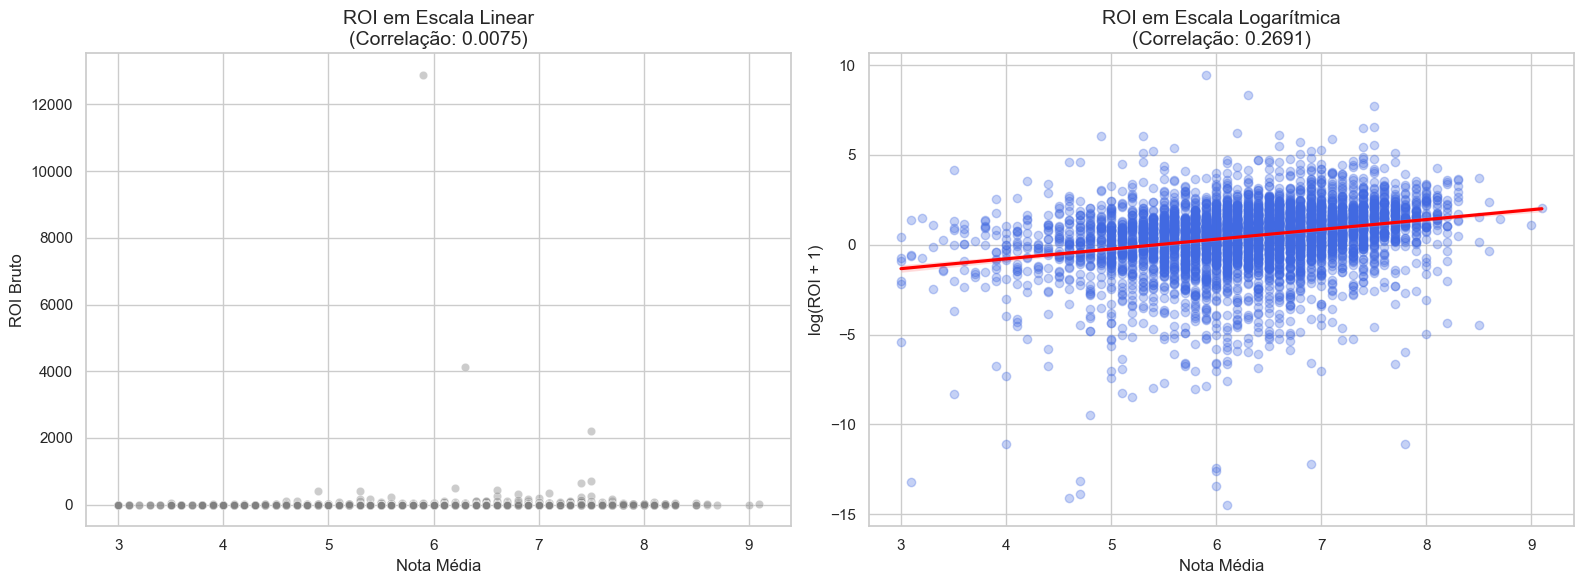

In [90]:
# Configurando o estilo
sns.set_theme(style="whitegrid")

# Criando a figura com dois gráficos para comparação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico Escala Linear (O Caos)
sns.scatterplot(data=df_roi, x='vote_average', y='roi', alpha=0.4, ax=ax1, color='gray')
ax1.set_title(f'ROI em Escala Linear\n(Correlação: 0.0075)', fontsize=14)
ax1.set_xlabel('Nota Média')
ax1.set_ylabel('ROI Bruto')

# 2. Gráfico Escala Logarítmica (A Linearidade Revelada)
# O regplot já desenha a linha de tendência da linearidade
sns.regplot(data=df_roi, x='vote_average', y='roi_log', 
            scatter_kws={'alpha':0.3, 'color':'royalblue'}, 
            line_kws={'color':'red'}, ax=ax2)

ax2.set_title(f'ROI em Escala Logarítmica\n(Correlação: 0.2691)', fontsize=14)
ax2.set_xlabel('Nota Média')
ax2.set_ylabel('log(ROI + 1)')

plt.tight_layout()
plt.show()

O gráfico à direita, que contém os valores normalizados, demonstra a correlação positiva entre o sucesso financeiro de um filme e a avaliação positiva, indicando que o ROI relativo normalizado também poderá se tornar uma featura no nosso modelo de recomendação de filmes.

In [91]:
# 1. Garantir que a coluna existe no df principal
df['roi_relativo'] = np.nan

# 2. Criar o mapeamento usando 'id' em vez de 'title'
# O 'id' é único para cada registro, então o InvalidIndexError desaparecerá
mapping_roi = df_roi.set_index('id')['roi_relativo']

# 3. Aplicar o mapeamento de volta para o df original
df['roi_relativo'] = df['id'].map(mapping_roi)

# 4. Validar a operação
print(f"Sucesso! Filmes sincronizados: {df['roi_relativo'].notna().sum()}")

Sucesso! Filmes sincronizados: 5307


In [92]:
# df['id'].unique()
len(df['id'])

41550

## **5ª Análise Exploratória**: Relação entre o gênero, a nota média, o ROI e a popularidade. ##

Como podemos observar abaixo, os dados inseridos na coluna genres estão dentro de listas de dicionários

In [93]:
display(df['genres'][0])

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

Para podermos trabalhar com esses dados, vamos explodir a coluna genres dentro de um novo dataframe, trazendo uma linha para cada gênero do mesmo título

In [94]:
import ast # Abstract Syntax Trees para converter string em lista com segurança

# 1. Função para extrair apenas os nomes dos gêneros
def extrair_generos(lista_str):
    try:
        # Converte a string da lista de dicionários em uma lista real
        lista = ast.literal_eval(lista_str)
        # Retorna apenas os nomes dos gêneros
        return [item['name'] for item in lista]
    except:
        # Caso o dado esteja corrompido ou seja NaN
        return []

# 2. Aplicando a extração no df_roi (para manter a consistência financeira)
df_roi['genres_list'] = df_roi['genres'].apply(extrair_generos)

# 3. "Explodindo" a coluna: se um filme tem 3 gêneros, ele vira 3 linhas
# Isso é essencial para calcular a média de ROI por gênero individualmente
df_generos = df_roi.explode('genres_list')
df_generos = df_generos.rename(columns={'genres_list': 'genre'})

# 4. Contando quantos gêneros únicos temos e quantos filmes por gênero
contagem_generos = df_generos['genre'].value_counts()

print(f"Total de gêneros únicos encontrados: {len(contagem_generos)}")
print("\nDistribuição de filmes por gênero:")
print(contagem_generos)

Total de gêneros únicos encontrados: 20

Distribuição de filmes por gênero:
genre
Drama              2546
Comedy             1821
Thriller           1490
Action             1398
Romance             989
Adventure           951
Crime               853
Science Fiction     633
Horror              581
Family              526
Fantasy             508
Mystery             441
Animation           289
History             233
War                 201
Music               190
Western              89
Documentary          56
Foreign              28
TV Movie              1
Name: count, dtype: int64


Aqui já temos um ponto de atenção: Há categorias com muito poucas amostras, como TV Movie e Foreign (Filme estrangeiro). <br>
Vamos analisar e entender se não podemos mesclá-las com outras categorias mais abrangentes.

In [95]:
df_generos.loc[df_generos['genre'] == 'TV Movie']['genres']

3148    [{'id': 10770, 'name': 'TV Movie'}, {'id': 12,...
Name: genres, dtype: object

Vamos remover a categoria "TV Movie" do DataSet para não enviesar o resultado

In [96]:
# Removendo apenas as linhas onde o gênero é 'TV Movie'
df_generos = df_generos[df_generos['genre'] != 'TV Movie']

# Verificando se a categoria sumiu
display(f"Gêneros restantes: {df_generos['genre'].unique()}")

"Gêneros restantes: ['Animation' 'Comedy' 'Family' 'Adventure' 'Fantasy' 'Drama' 'Romance'\n 'Action' 'Crime' 'Thriller' 'History' 'Science Fiction' 'Mystery'\n 'Horror' 'War' 'Documentary' 'Western' 'Music' nan 'Foreign']"

Por fim, vamos calcular as medianas do ROI relativo e da popularidade e analisar os resultados

In [97]:
# Agrupando por gênero e calculando as medianas
ranking_generos = df_generos.groupby('genre').agg({
    'roi_relativo': 'median',
    'popularity': 'median',
    'budget': 'median',
    'id': 'count'
}).rename(columns={'id': 'total_filmes'}).sort_values(by='roi_relativo', ascending=False)

# Exibindo o ranking
display(ranking_generos)

,roi_relativo,popularity,budget,total_filmes
genre,,,,
Animation,0.432973,11.358363,53000000.0,289
Family,0.432834,10.231988,40000000.0,526
Documentary,0.430738,3.090025,2000000.0,56
Horror,0.37451,8.768288,10000000.0,581
Fantasy,0.318664,10.805184,40000000.0,508
Adventure,0.31848,10.695639,40000000.0,951
Comedy,0.287501,7.906434,18000000.0,1821
Action,0.273533,9.670427,30000000.0,1398
Romance,0.271344,7.366331,14000000.0,989


Agora vamos plotar esses dados em um gráfico de dispersão e seguir para as conclusões

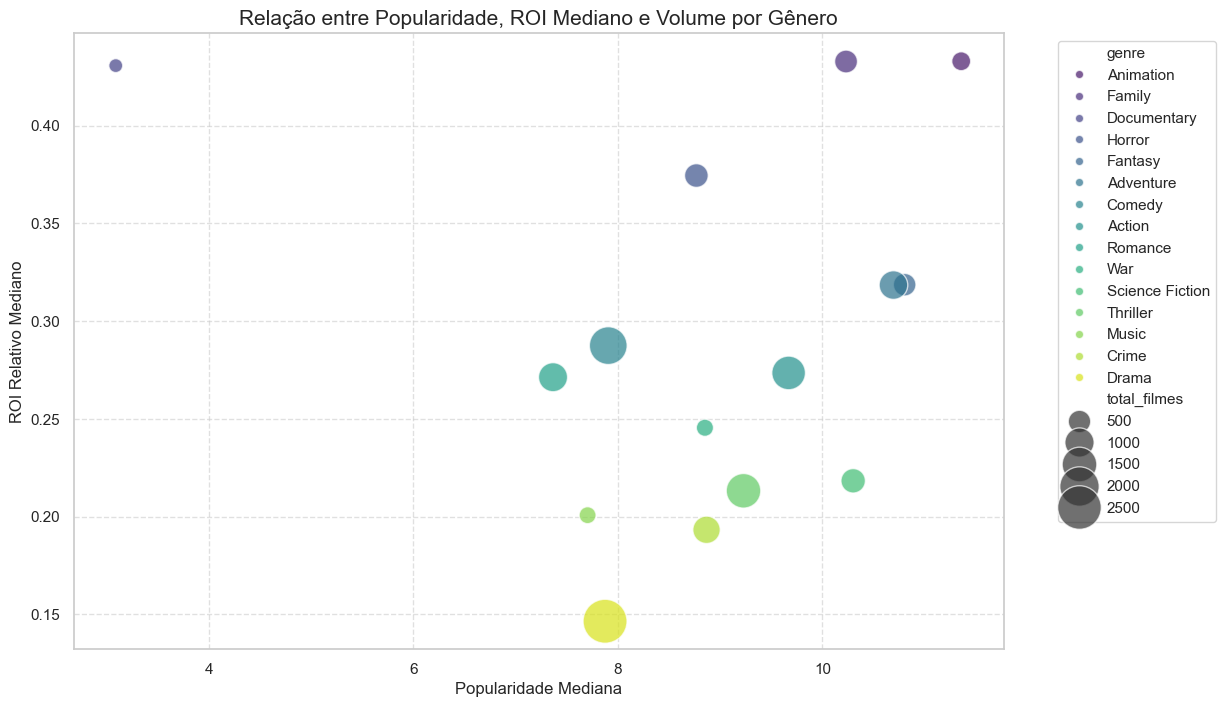

In [98]:
# Preparando os dados do ranking
top_generos = ranking_generos.head(15)

plt.figure(figsize=(12, 8))
# Gráfico de bolhas: X=Popularidade, Y=ROI, Tamanho=Quantidade de Filmes
sns.scatterplot(data=top_generos, x='popularity', y='roi_relativo',
                size='total_filmes', sizes=(100, 1000), hue='genre', palette='viridis', alpha=0.7)

plt.title('Relação entre Popularidade, ROI Mediano e Volume por Gênero', fontsize=15)
plt.xlabel('Popularidade Mediana')
plt.ylabel('ROI Relativo Mediano')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- Comparativamente, existem bem menos filmes de animação do que a maioria das demais categorias, provavelmente pela complexidade de produção e o seu custo. Em contrapartida, é a categoria que apresenta o maior ROI e popularidade, motivado pelo seu amplo público infantil.<br><br>
- A categoria família é muitas vezes compartilhada com a categoria Animação, conforme conseguimos observar as intersecções na amostra apresentada acima. Isso alavanca a sua posição também.<br><br>
- Por outro lado, a categoria terror também apresenta um ROI bastante elevado mesmo se concentrando em um público mais adulto. Isso se deve a filmes que, mesmo com orçamento bastante reduzido, tiveram um sucesso de bilheteria maior<br><br>
- Documentários tendem a ter um ROI notavelmente alto, apesar de serem de um público bastante nichado. Muito por conta de terem um orçamento consideravelmente reduzido, quando comparado aos de filmes.<br><br>
- Por fim, existe uma coleção muito maior de filmes categorizados como Drama, o que aumenta a variabilidade de ROIs também. Essa concorrência no mercado por títulos de drama também tende a torná-lo "só mais um", reduzindo a sua popularidade e principalmente o ROI mediano.

In [99]:
import ast

# Vamos transformar a coluna de gêneros em listas de nomes
def limpar_generos(coluna):
    try:
        lista = ast.literal_eval(coluna)
        return [d['name'] for d in lista]
    except:
        return []

df['genres_list'] = ''

# Criando a coluna limpa no DF principal
df['genres_list'] = df['genres'].apply(limpar_generos)

In [100]:
# Salvando o DataFrame limpo em um novo arquivo CSV
df.to_csv('archive/movies_metadata_limpo.csv', index=False)

## **Finalização da Análise Exploratória** ##

Após uma investigação profunda nos dados de mais de 40.000 títulos, esta análise exploratória forneceu as bases sólidas necessárias para a construção de um motor de recomendação inteligente. Os principais aprendizados foram:

1. Integridade e Tratamento de Dados
Limpeza Estratégica: Identificamos e removemos inconsistências críticas, como duplicatas de IDs e registros com orçamentos irreais (abaixo de US$ 1.000), garantindo que os cálculos de ROI não fossem distorcidos por erros de preenchimento.

Engenharia de Atributos: A criação da métrica ROI Relativo foi fundamental para neutralizar o efeito da inflação e das mudanças de mercado ao longo das décadas, permitindo comparar filmes de épocas distintas sob a mesma régua financeira.

2. O Poder da Escala Logarítmica
Revelação de Tendências: A aplicação de transformações logarítmicas nas variáveis de Popularidade e ROI permitiu que a correlação entre a nota crítica e o sucesso financeiro saltasse de um valor desprezível (0.0075) para uma relação positiva relevante (0.2691).

Implicação: Isso prova que, embora a nota não seja o único fator de sucesso, ela é um preditor viável que o algoritmo de recomendação deve considerar.

3. Dinâmica de Gêneros
Desempenho por Categoria: Gêneros como Animation e Adventure mostraram-se os mais resilientes, apresentando as maiores medianas de popularidade e retorno financeiro.

Estratégia de Recomendação: O sistema poderá utilizar esses pesos de gênero para resolver o problema de "Cold Start", sugerindo títulos de gêneros historicamente bem-sucedidos quando houver poucos dados específicos sobre um novo filme.